# Bear Spring EPM (Equivalent Porous Media) Model

Model started 10/14/24. Modeled after Langevin, C. 2024, UMN Hydrocamp  
[Link to Reference Code](https://github.com/langevin-usgs/umn2024/tree/main)

This is a copy of the actual EPM model that is designed solely to figure out how to get the watershed geoJSON file to fit onto a model grid with the appropriate Coordinate Reference System

### To Do
- Finish multilayer model

In [1]:
# import python packages
import pathlib as pl #Pathlib used for switching between directories, accessing files
import numpy as np #for numerical operations
import matplotlib.pyplot as plt #for creating plots
import pandas as pd #for handling dataframes
import flopy #Used for interacting with MODFLOW, developing MODFLOW inputs and reading outputs
import rasterio #For working with raster data and shapefiles
import geopandas as gpd #For importing shapefiles
import shapely as shp
from shapely import vectorized
import networkx as nx
import geojson
import os
import sys
import importlib
import yaml
import seaborn as sns


In [2]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages

In [9]:
import utils.utils
import utils.config
import utils.creeks
importlib.reload(utils.utils)
importlib.reload(utils.config)
importlib.reload(utils.creeks)
from utils.config import *
from utils.utils import *
from utils.creeks import *


new config loaded from config.yaml
loaded watershed geojson
loaded springshed geojson
loaded creeks geojson
loaded subdomain geojson
loaded karst_features csv
loaded sinkholes csv
loaded precip csv
extracted watershed polygon
extracted springshed polygon
extracted subdomain polygon
merged ('watershed_polygon', 'springshed_polygon')
loaded new Creek object from creeks data
set domain to subdomain_polygon
(552594.40655525, 4866235.880722723, 561054.4101949929, 4870845.335745172)
applied DEM ../../src/data/DEM/dem_1m_m.bil to domain
converted start tuple to Point
added segment from POINT (557455.9219013986 4866985.336331408) to POINT (557644.4070525824 4866235.880722723)

converted start tuple to Point
added segment from POINT (560184.9218932291 4868831.33646198) to POINT (560584.4090987638 4869035.8773543835)

clipped creeks
added sink
added spring
extracted grid params: 
Lx = 8460.003639742848
Ly = 4609.455022448674
nrow = 921
ncol = 1692
nlay = 2
set top to DEM


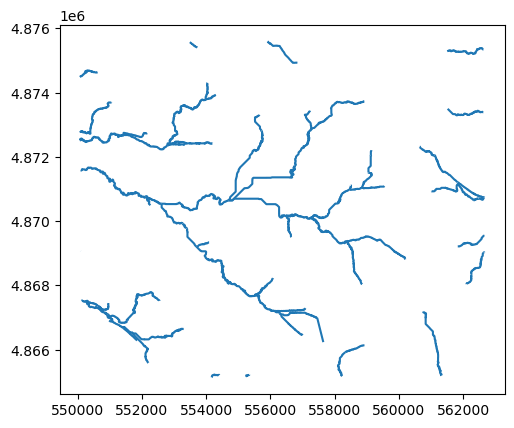

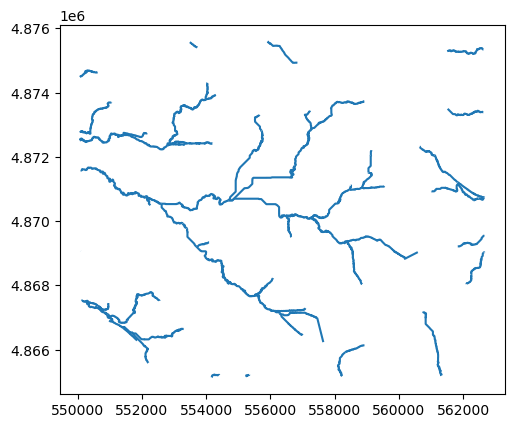

In [10]:
test = Config('config.yaml')
test.load_polygon('watershed', 'springshed', 'subdomain')
test.merge_polygons('merged', 'watershed_polygon', 'springshed_polygon')
test.load_creeks()
test.set_domain('subdomain_polygon')
test.apply_DEM_to_domain()
start = test.creeks.return_coordinates(186)[-1]
nearest = get_nearest_point(start, test.merged_polygon)
test.creeks.extend_creek(start, nearest)
start = test.creeks.return_coordinates(154)[-1]
nearest = get_nearest_point(start, test.merged_polygon)
test.creeks.extend_creek(start, nearest)
test.creeks.clip_creek(test.domain, 10)
test.load_karst_features()
test.extract_grid_params_from_domain()
test.extract_top_config()


In [11]:
test.extract_bottom_config()
test.create_grid()
test.extract_idomain()
test.extract_K_values()



set bottom array


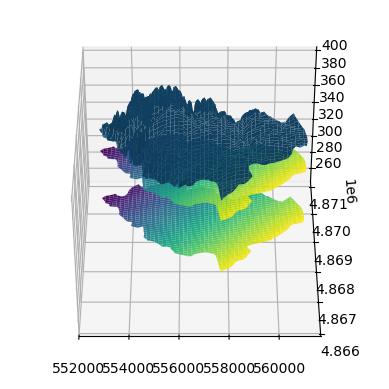

In [12]:
test.plot_model_grid_layers(azim = 270, elev = 40) 


<Axes: xlabel='UTME', ylabel='UTMN'>

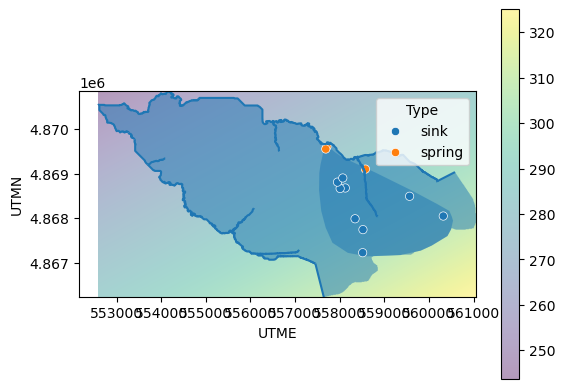

In [107]:
fig, ax = plt.subplots()
# plt.imshow(test.dem_grid, extent = [test.total_bounds[0], test.total_bounds[2], test.total_bounds[1], test.total_bounds[3]], alpha = 0.4)
plt.imshow(test.botm_elev[0], extent = [test.total_bounds[0], test.total_bounds[2], test.total_bounds[1], test.total_bounds[3]], alpha = 0.4)
plt.colorbar()
test.domain.plot(ax = ax, alpha = 0.5)
test.creeks.plot(ax = ax)
test.plot_polygons('springshed_polygon', ax= ax, alpha= 0.5)
sns.scatterplot(test.karst_features, x = 'UTME', y = 'UTMN', hue = 'Type')


## Load External Data

Import the Sinkhole and Spring Data  
Import Watershed data  
Import Bear Creek Location Data  
Import Precipitation Data

In [2]:
home_dir = 'C:/Users/huan1428/Documents/karst/UMNBearSpring'

In [6]:
geoJSON = '../data/HUC_12.geojson'
springshed_geojson = '../data/Bear_Springshed.geojson'
creeks_geojson = '../data/creeks_geoJSON.geojson'
watershed = load_geojson(geoJSON)
wsPolygon = extract_polygon(watershed)
creeks = test.creeks.data
springshed = load_geojson(springshed_geojson)
bsPolygon = extract_polygon (springshed)
subDomain = test.domain


In [7]:
wsMerged = combine_polygons(wsPolygon, bsPolygon)
dem_grid = test.dem_grid

In [ ]:

#Import the karst feature data (UTME, UTMN, elevation data)
f = pl.Path('../data/karst_features.csv')
karst_df = pd.read_csv(f)
karst_df = karst_df.set_index("ID") #Set the index for the karst dataframe to the feature name
karst_df['Elevation_m'] = karst_df['Elevation_ft'] * 0.3048 # create a new col. with the m elevation

#Isolate the spring and sinkhole coordinates for plotting on DEM
springs = karst_df[karst_df['Type'] == 'spring' ] #get springs
sinkholes = karst_df[karst_df['Type'] == 'sink' ] #get sinkholes

#Import the creek data shapefile
creeks = gpd.read_file('../data/creeks_geoJSON.geojson')
creeks = creeks.to_crs(wsPolygon.crs) #Set the coordinate reference system for the shapefile
creeks = gpd.clip(creeks, wsPolygon) #Mask out all the shapefile data that is not inside of the wsPolygon

#Import the precipitation data for the month of may (daily totals)
f = pl.Path('../data/BS_precip_5_1_24_5_30_24.csv')
precip_df = pd.read_csv(f)
precip_df = precip_df.drop(columns = ['NAME', 'SNOW', 'SNWD', 'STATION']) #remove unecessary columns
precip_df = precip_df.set_index("DATE") # Set the Date values as the indices for the array
precip_df['PRCP'] = precip_df['PRCP'] * 0.001 #convert from mm to meters
precip_df['time'] = range(len(precip_df))

#Import the discharge data for the month of may



In [5]:
%%time

#Create helper functions

#Get karst feature data from karst_df
def get_karst_data(ID):
    return karst_df.loc[ID].to_dict()

#Get DEM elevation data for a karst feature point
def get_cell_elev(ID):
    k_feat = get_karst_data(ID)
    i, j = sg.intersect(k_feat['UTME'], k_feat['UTMN'])
    elev = dem_grid[i,j]
    #print(f'Feature ID: {ID},row: {i}, col: {j}, DEM_elev: {elev} ')
    return elev, i, j

#Get elevations, cell i, j intersections for the structured grid with the creek
def get_creek_cells(creek, conductance = 50):
    river_cells = set() #Initialize a list of the cells where the creek meets the sg
    #iterate over the line segment of the creek shapefile
    for line in creek.geometry:
        for coord in list(line.coords): #Access each coordinate in the line for the shapefile
            x , y = coord
            i, j = sg.intersect(x,y)
            # Check if the cell is in the active domain
            if idomain[0, i, j] == 1:  # Assuming idomain is 3D (nlay, nrow, ncol)
                elev = dem_grid[i, j]
                river_cells.add((0, i, j, elev, conductance))
    return list(river_cells)

#Get elevations, i, j intersections for the structured grid with the creek
def get_creek_cellsv2(creek, sg, dem_grid, idomain, conductance = 50):
    river_cells = set()
    creek_line = shp.geometry.LineString([pt for line in creek.geometry for pt in line.coords])
    
    #Iterate through cells in order to find where there are intersections, record these cells
    for line in creek.geometry:
        # Convert to a LineString object (each branch of the creek)
        creek_line = shp.geometry.LineString(line.coords)
        
        # Iterate through all grid cells
        for i in range(sg.nrow):
            for j in range(sg.ncol):
                if idomain[0, i, j] == 1:  # Only check active cells
                    # Get cell vertices and create a Polygon
                    vertices = sg.get_cell_vertices(i, j)
                    cell_poly = shp.geometry.Polygon(vertices)
                    
                    # Check if the creek segment intersects the cell
                    if creek_line.intersects(cell_poly):
                        elev = dem_grid[i, j]
                        river_cells.add((0, i, j, elev, conductance))

    return list(river_cells) 



def get_creek_cellsv3(creek, sg, dem_grid, idomain, conductance=50):
    river_cells = set()

    # Convert creek geometry to PyGEOS geometries
    creek_geoms = [pygeos.linestrings(line.coords) for line in creek.geometry]
    creek_tree = STRtree(creek_geoms)

    # Iterate through grid cells
    for i in range(sg.nrow):
        for j in range(sg.ncol):
            if idomain[0, i, j] == 1:  # Only check active cells
                # Get cell vertices and create a PyGEOS Polygon
                vertices = sg.get_cell_vertices(i, j)
                cell_poly = pygeos.polygons(vertices)

                # Query the spatial index for intersecting creek geometries
                intersecting_indices = creek_tree.query(cell_poly, predicate="intersects")

                # If there are intersections, record the cell
                if len(intersecting_indices) > 0:
                    elev = dem_grid[i, j]
                    river_cells.add((0, i, j, elev, conductance))

    return list(river_cells)


def repair_missing_creek_cells(creek, sg, dem_grid, idomain, river_cells, conductance=50):
    # Convert river_cells to a set for efficient operations
    river_cells_set = set(river_cells)

    # Iterate through the creek geometry
    for line in creek.geometry:
        creek_line = shp.geometry.LineString(line.coords)

        # Iterate through all grid cells
        for i in range(sg.nrow):
            for j in range(sg.ncol):
                if idomain[0, i, j] == 1:  # Only check active cells
                    vertices = sg.get_cell_vertices(i, j)
                    cell_poly = shp.geometry.Polygon(vertices)

                    # Find boundary-adjacent cells not already in river_cells
                    if creek_line.intersects(cell_poly) and (0, i, j, dem_grid[i, j], conductance) not in river_cells_set:
                        # Add missing creek cells to the set
                        river_cells_set.add((0, i, j, dem_grid[i, j], conductance))

    # Return as a list for consistency with the original function
    return list(river_cells_set)


# Ensure "island" cells are deactivated using flood-fill algorithm
def remove_isolated_cells(idomain):
    for k in range(idomain.shape[0]):  # Iterate over layers
        # Label connected components of active cells
        labeled_array, num_features = scipy.ndimage.label(idomain[k] == 1)
        
        # Find sizes of each connected component
        component_sizes = np.bincount(labeled_array.ravel())
        
        # Keep only the largest connected component (or set threshold for size)
        largest_component = np.argmax(component_sizes[1:]) + 1  # Ignore 0 (inactive cells)
        
        # Deactivate isolated cells
        idomain[k][labeled_array != largest_component] = 0

#Get locations of cells in list form
def get_nodes(locs):
    nodes = []
    for k, i, j in locs:
        nodes.append(k * nrow * ncol + i * ncol + j)
    return nodes

CPU times: total: 0 ns
Wall time: 0 ns


## Build the domain from the above GeoJSON, shapefiles

CPU times: total: 109 ms
Wall time: 108 ms


<timed exec>:13: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler


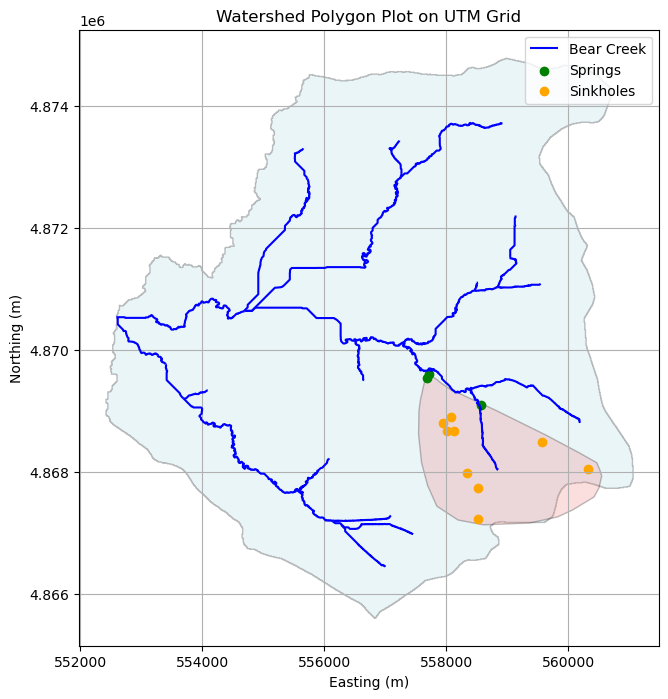

In [44]:
%%time

# Plot the polygon using the correct CRS to ensure that the bounds are in the right coordinate system and that the polygon looks correct
fig, ax = plt.subplots(figsize=(8, 8))
wsPolygon.plot(ax=ax, color='lightblue', edgecolor='black', alpha = 0.25, label = 'Watershed Area')
bsPolygon.plot(ax=ax, color='lightcoral', edgecolor='black', alpha = 0.25, label = 'Springshed Area')
creeks.plot(ax=ax, color='blue', label='Bear Creek')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.title('Watershed Polygon Plot on UTM Grid')
plt.grid(True)
#Plot the springs and sinkholes on this grid
plt.scatter(springs['UTME'], springs['UTMN'], color = 'green', label='Springs')
plt.scatter(sinkholes['UTME'], sinkholes['UTMN'], color='orange', label = 'Sinkholes')
plt.legend()

The polygon is Valid: 0    True
dtype: bool


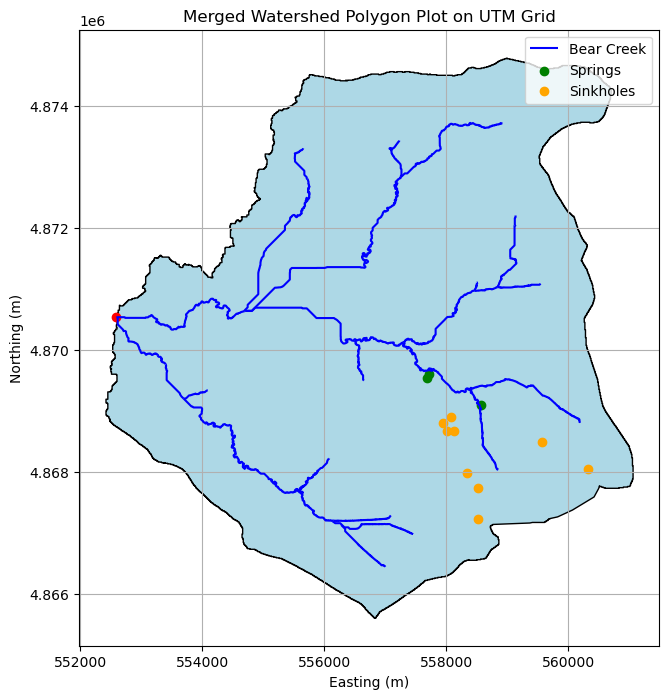

CPU times: total: 250 ms
Wall time: 231 ms


In [45]:
%%time
#Combine the polygons into a collective list
polygons = list(wsPolygon['geometry']) + list(bsPolygon['geometry'])

#Merge the polygon list into a singular polygon covering the watershed and springshed
merged = shp.ops.unary_union(polygons)

#Convert the merged polygon to a GeoDataFrame (gdf) object
wsMerged = gpd.GeoDataFrame([{'geometry': merged}], crs=projected_crs)

#repair the geometry for any errors that make the polygon not valid
wsMerged.loc[:,'geometry'] = wsMerged['geometry'].apply(shp.make_valid)
print(f'The polygon is Valid: {wsMerged.is_valid}')
wsMerged = wsMerged.explode(index_parts=True)

#Plot the new domain shape from the merged polygons
label = False #Flag for turning the creek linestring labels on/off
fig, ax = plt.subplots(figsize=(8, 8))
wsMerged.plot(ax=ax, color = 'lightblue', edgecolor = 'black')
creeks.plot(ax=ax, color='blue', label='Bear Creek')

#Label each of the linestrings for the creeks GDF
if label == True:
    for _, creek in creeks.iterrows():
        creek_geom = creek['geometry']

        midpoint = creek_geom.interpolate(0.5, normalized = True)

        ax.text(midpoint.x, midpoint.y, str(creek['FID']), color='k', fontsize=12, ha='center')

plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.title('Merged Watershed Polygon Plot on UTM Grid')
plt.grid(True)
#Plot the springs and sinkholes on this grid
plt.scatter(springs['UTME'], springs['UTMN'], color = 'green', label='Springs')
plt.scatter(sinkholes['UTME'], sinkholes['UTMN'], color='orange', label = 'Sinkholes')
plt.scatter(552594.407, 4870544.353, color='red')
plt.legend()
plt.show()
#Get the new bounds of the merged polygon
bounds = wsMerged.total_bounds

In [ ]:
%%time
#Select the stream segments to extend to the watershed boundary
fids = [186, 154]
select_creeks = creeks[creeks['FID'].isin(fids)]

coords0 = list(select_creeks.iloc[0].geometry.coords)[-1]
coords0 = shp.geometry.Point(coords0)
coords1 = list(select_creeks.iloc[1].geometry.coords)[-1]
coords1 = shp.geometry.Point(coords1)

#Get the boundary for the watershed
wsBoundary = wsMerged.geometry.iloc[0].boundary

#Find the nearest points from the end of the selected creeks to the boundary
nearest0 = shp.ops.nearest_points(coords0, wsBoundary)
nearest1 = shp.ops.nearest_points(coords1, wsBoundary)
nearest_point0 = nearest0[1]
nearest_point1 = nearest1[1]

#Plot the new points
fig, ax = plt.subplots(figsize=(8, 8))
wsMerged.boundary.plot(ax=ax, color = 'k', edgecolor = 'black')
select_creeks.plot(ax=ax, color='blue', label='Bear Creek')
plt.scatter(nearest_point0.x, nearest_point0.y, color = 'red')
plt.scatter(coords0.x, coords0.y, color = 'green')
plt.scatter(nearest_point1.x, nearest_point1.y, color = 'red')
plt.scatter(coords1.x, coords1.y, color = 'green')

#Now add in the line segment connecting the
#creeks to the boundary cells nearest to them
#build new line segments
segment0 = shp.geometry.LineString([coords0, nearest_point0])
segment1 = shp.geometry.LineString([coords1, nearest_point1])

#convert line segments to geodataframe objects
segment0_gdf = gpd.GeoDataFrame(
    {'FID': [max(select_creeks['FID']) + 1]},  # Assign a unique FID
    geometry=[segment0],
    crs=select_creeks.crs  # Use the same CRS as the original creeks GeoDataFrame
)

segment1_gdf = gpd.GeoDataFrame(
    {'FID': [max(select_creeks['FID']) + 1]},  # Assign a unique FID
    geometry=[segment1],
    crs=select_creeks.crs  # Use the same CRS as the original creeks GeoDataFrame
)

AttributeError: 'Polygon' object has no attribute 'geometry'

In [ ]:
%%time

#Combine the creeks together with the selected creeks
new_creeks = pd.concat([select_creeks, segment0_gdf], ignore_index=True)
new_creeks = pd.concat([new_creeks, segment1_gdf], ignore_index=True)

#combine the newly made creeks with the existing creek deliniations
creeks = pd.concat([creeks, new_creeks], ignore_index=True)


NameError: name 'select_creeks' is not defined

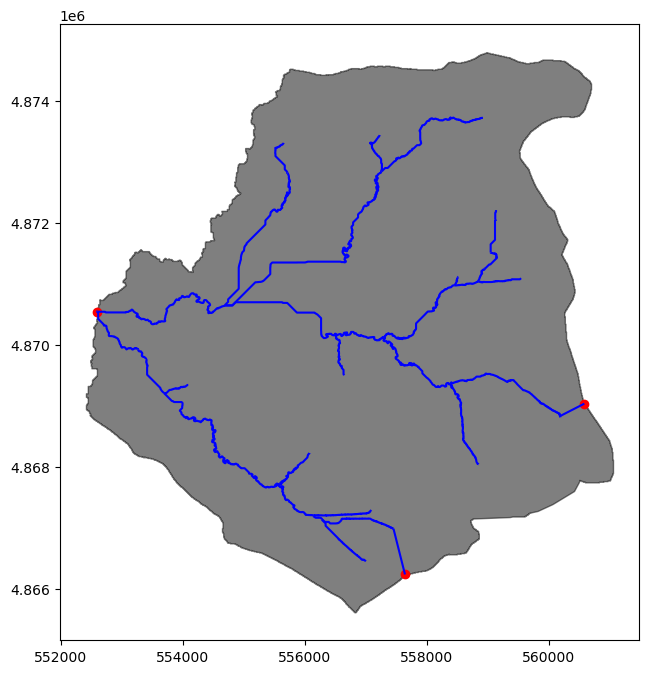

In [46]:

#Find the intersection points where the boundary intersects with the creek
intersections = creeks.geometry.apply(lambda line: line.intersection(wsMerged.boundary)) #TODO: why are only 2 points being found? 
intersections_points = intersections[intersections.geom_type == "Point"]

unique_points = list({(point.x, point.y) for point in intersections_points})
# unique_points.append((552594.407, 4870544.353)) #TODO: fix this manual boundary

#Plot the new creeks and the intersection points on a plot
label = False #Flag for turning the creek linestring labels on/off
fig, ax = plt.subplots(figsize=(8, 8))
gpd.GeoDataFrame(geometry = [wsMerged]).plot(ax=ax, color = 'k', alpha = 0.5, edgecolor = 'black')
creeks.plot(ax=ax, color='blue', label='Bear Creek')
for pt in unique_points:
    plt.scatter(pt[0], pt[1], color='red')

if label == True:    
    for _, creek in creeks.iterrows():
        creek_geom = creek['geometry']

        midpoint = creek_geom.interpolate(0.5, normalized = True)

        ax.text(midpoint.x, midpoint.y, str(creek['FID']), color='k', fontsize=12, ha='center')

Subdomain Area: 18.75 Km^2


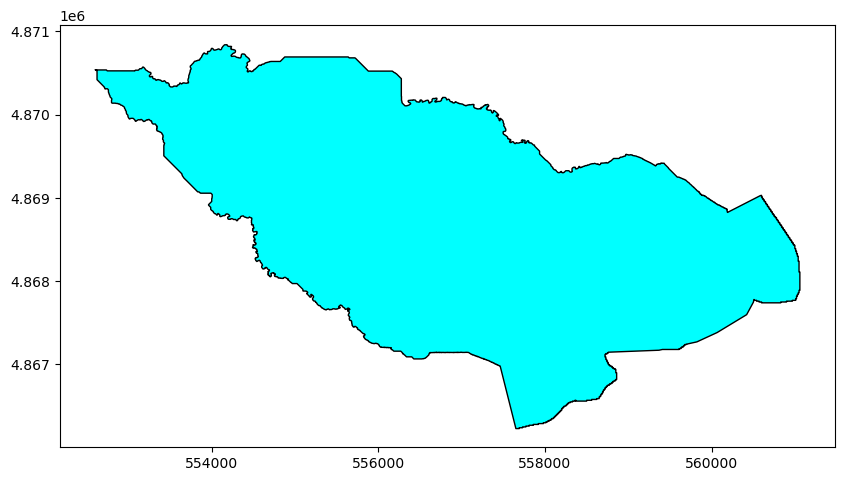

In [101]:
# %%time
G = nx.Graph()
#Define a function to find the shortest path from each point through the creek network
for idx, line in creeks.iterrows():
    coords = list(line.geometry.coords)
    G.add_edge(tuple(coords[0]), tuple(coords[-1]), geometry = line.geometry)
    
#build a fxn for finding the shortest path between two points in a network
def find_shortest_path(G, start_point, end_point):
    #Find the nearest node for the start and end points
    start_node = min(G.nodes, key=lambda node: shp.geometry.Point(node).distance(start_point))
    end_node = min(G.nodes, key=lambda node: shp.geometry.Point(node).distance(end_point))
    
    #find the shortest path between these nodes
    path = nx.shortest_path(G, source=start_node, target=end_node)
    return path

#Convert the coordinate tuples to point objects
points = [shp.geometry.Point(coords) for coords in unique_points]
#find shortest path along creeks
pathAC = find_shortest_path(G, points[0], points[1])
pathBC = find_shortest_path(G, points[2], points[1])

#Convert these paths (sets of nodes) into LineStrings
linesAC = [G.edges[pathAC[i], pathAC[i + 1]]['geometry'] for i in range(len(pathAC) - 1)]
linesBC = [G.edges[pathBC[i], pathBC[i + 1]]['geometry'] for i in range(len(pathBC) - 1)]

#Merge these lines into continuous paths
AC = shp.ops.linemerge(linesAC)
BC = shp.ops.linemerge(linesBC)

#Get the domain boundary along the watershed boundary
# Convert LineString to a list of coordinates
boundary_coords = list(wsMerged.boundary.coords)

# Find nearest boundary coordinates for Points A and B
def find_nearest_index(coords, point):
    return np.argmin([shp.ops.Point(c).distance(point) for c in coords])

index_a = find_nearest_index(boundary_coords, points[0]) #find nearest starting point to the intersection points defined above 
index_b = find_nearest_index(boundary_coords, points[2])

# Create two paths: clockwise and counterclockwise
if index_a < index_b:
    path1 = boundary_coords[index_a:index_b + 1]
    path2 = boundary_coords[index_b:] + boundary_coords[:index_a + 1]
else:
    path1 = boundary_coords[index_b:index_a + 1]
    path2 = boundary_coords[index_a:] + boundary_coords[:index_b + 1]

# Convert paths to LineStrings and select the shorter one
path1_ls = shp.geometry.LineString(path1)
path2_ls = shp.geometry.LineString(path2)

wsSegment =min(path1_ls, path2_ls, key=lambda ls: ls.length)
#Get the boundary for the creek paths developed above
#Get the projected points on the constructed lines

#AC
AC_start = AC.project(points[0])
AC_end = AC.project(points[1])
acSegment = shp.ops.substring(AC, AC_start, AC_end)

#BC
BC_start = BC.project(points[2])
BC_end = BC.project(points[1])
bcSegment = shp.ops.substring(BC, BC_start, BC_end)

#Convert to a singular shape
subDomain_coords = (
    list(acSegment.coords) +
    list(bcSegment.coords[::-1]) +
    list(wsSegment.coords[::-1])
)

#create trianlge Polygon
subDomain_poly = shp.geometry.Polygon(subDomain_coords)

#Convert to GDF object
# Plot the result
subDomain = gpd.GeoDataFrame(
    {'geometry': [subDomain_poly]},
    crs=test.crs  # Use CRS of your original data
)

subArea = subDomain['geometry'].area.sum()/1e6
print(f'Subdomain Area: {subArea:.2f} Km^2')

#subDomain is the new domain that is selected between the two creeks
# Plot
ax = subDomain.plot(color="cyan", edgecolor="black", figsize=(10, 8))
plt.show()


In [103]:
subDomain.to_file('../../src/data/mf6_modelData/creek_subdomain.geojson', driver = 'GeoJSON')

## Apply the subdomain above to the DEM

NameError: name 'springs' is not defined

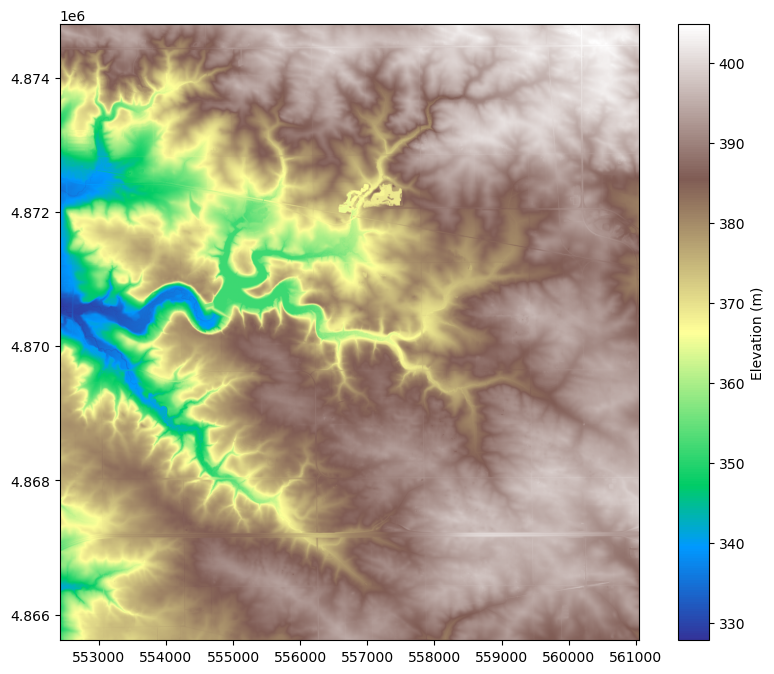

In [32]:
%%time
#Import the DEM data
bounds = wsMerged.total_bounds
with rasterio.open('../../src/data/DEM/dem_1m_m.bil') as src: #note to self: make sure all the bil files are in the directory
    # Define the window of useful data (in UTM coords) from the larger DEM shapefile
    window = rasterio.windows.from_bounds(bounds[0], bounds[1], bounds[2], bounds[3], transform=src.transform)
    extent = rasterio.windows.bounds(window, src.transform)  # Get window boundaries to confirm they are correct
    
    # Read only the windowed portion of the DEM
    dem_data = src.read(1, window=window)
    
    # Mask out the erroneous data (excessively large values due to data errors)
    maxval = 10000
    dem_data = np.ma.masked_where(dem_data > maxval, dem_data)
    
    # Get the corresponding transform for plotting
    window_transform = src.window_transform(window)
    
# Plot DEM as a color plot to evaluate all of the values and establish the value range and units
fig, ax = plt.subplots(figsize=(10, 8))
dem_plot = ax.imshow(
    dem_data,
    cmap='terrain',
    extent=[extent[0], extent[2], extent[1], extent[3]],
    origin='upper'
)
# Add a colorbar for the DEM
cbar = plt.colorbar(dem_plot, ax=ax, label='Elevation (m)')
# Plot springs and sinkholes on the DEM
ax.scatter(
    springs['UTME'], springs['UTMN'],
    color='green', label='BSS Springs', marker='o', edgecolor='black'
)
ax.scatter(
    sinkholes['UTME'], sinkholes['UTMN'],
    color='orange', label=' Traced Sinkholes', marker='x'
)
# Overlay the merged watershed (wsMerged GeoDataFrame)
wsMerged.boundary.plot(ax=ax, color='k', linewidth=1, label='HUC-12 Watershed Boundary')
#Overlay the Springshed Area (Should be within the merged area)
bsPolygon.boundary.plot(ax=ax, color ='red', linewidth=1, label ='BSS Boundary')
#Overlay the creeks
creeks.plot(ax=ax, color= 'blue', linewidth=1, label='Creeks')
#overlay the subdomain area between the creeks
subDomain.boundary.plot(ax=ax, color= 'magenta', label= 'Subdomain Boundary', linewidth = 2)
# Add labels and title
ax.set_xlabel('UTME')
ax.set_ylabel('UTMN')
ax.set_title('Bear Springshed and Bear Creek Watershed', fontsize = 18)
ax.legend()

plt.show()


#print the boundary values of the DEM
for i in range(len(extent)):
    print(f'Current UTM Boundary: {extent[i]}')

## Create the MODFLOW Model Grid

Place the grid onto real world coordinates for use with the DEM data and geological data

In [25]:
#Construct a new set of bounds using the newly formed polygon
bounds = subDomain.total_bounds
print(f'min x: {bounds[0]}, min y: {bounds[1]}, max x: {bounds[2]}, max y: {bounds[3]}')

#Re-adjust the cell size, domain of the model, ncol, nrow, based on the domain change
Lx = bounds[2] - bounds[0]
Ly = bounds[3] - bounds[1]
delr = 5.0 #m
delc = 5.0 #m
ncol = int(Lx / delc)
nrow = int(Ly / delr)

#Re-import the new DEM_Grid with the updated boundaries from the subDomain
with rasterio.open('../../src/data/DEM/dem_1m_m.bil') as src:
    #define the window of useful data(in UTM coords) from the larger DEM shapefile
    window = rasterio.windows.from_bounds(bounds[0], bounds[1], bounds[2], bounds[3], transform=src.transform)
    extent = rasterio.windows.bounds(window, src.transform)#get window boundaries to confirm they are correct
    
    #convert all of the data to a grid so it can be used with the MODFLOW model
    width = ncol#set the width of the grid
    height = nrow #set the height of the grid
    # transform = rasterio.transform.from_bounds(*extent, width, height) #transform the data to the grid
    
    #Import the DEM and apply it to the grid
    dem_grid = src.read(
    1,
    out_shape = (height, width),
    window = window,
    resampling= rasterio.enums.Resampling.bilinear
    )
    
    #mask out the erroneous data (excessively large values due to data errors)
    maxval = 10000
    dem_grid = np.ma.masked_where(dem_grid > maxval, dem_grid)

min x: 552594.40655525, min y: 4866235.880722723, max x: 561054.4101949929, max y: 4870845.335745172


In [26]:
%%time

#generate the grid properties top, bottom, nlay, that are not defined in the grid construction above
nlay = 1
top = dem_grid #Set the upper elevation boundary for the single layer model
botm = np.ones((nlay, nrow, ncol), dtype = float) #contruct the array which will beomce the bottom array
botm_elev = 325.044 #Top of the decorah shale THIS VALUE IS NOT CORRECT, ONLY IN TEMPORARILY
#assign elevations for bottoms of the units
botm[0] = botm_elev #This will eventually be changed by the angled botm array

#Convert delc and delr to an array for input into the sg object
delr = delr * np.ones(ncol, dtype = float)
delc = delc * np.ones(nrow, dtype = float)

# Generate the model grid in flopy
sg = flopy.discretization.StructuredGrid(
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    delr=delr,
    delc=delc,
    top=top,
    botm=botm,
    xoff=bounds[0],
    yoff=bounds[1],
    crs= 'EPSG:32615'
)

CPU times: total: 15.6 ms
Wall time: 22.5 ms


In [78]:
%%time

#Get coordinates for sinkholes and springs in terms of i, j on the modelgrid

#Get all of the coordinates for the sinkholes
sinkhole_cells = [] #create an empty list for the sinkhole data
for i in range(len(karst_df[karst_df['Type'] == 'sink'])):
    df = karst_df[karst_df['Type'] == 'sink']
    sinkhole = df.iloc[i]
    elev, row, col = get_cell_elev(sinkhole.name)
    sinkhole_cells.append((sinkhole.name, elev, row, col))

#get all of the coordinates for the springs (NOT including Bear Spring)
spring_cells = [] #create an empty list for the sinkhole data
for i in range(len(karst_df[karst_df['Type'] == 'spring'])):
    df = karst_df[karst_df['Type'] == 'spring']
    spring = df.iloc[i]
    elev, row, col = get_cell_elev(spring.name)
    spring_cells.append((spring.name, elev, row, col))

CPU times: total: 15.6 ms
Wall time: 40.5 ms


#### Note to self, the issue is NOT witht he for loop (although it still could be helpful to use the for loop parallization after) but the inefficiency is in the ixp = gi.intersect(domain) operation

c:\Users\huan1428\.conda\envs\modflow6\Lib\site-packages\flopy\utils\gridintersect.py:123: DeprecationWarning: Note `method="structured"` is deprecated. Pass `method="vertex"` to silence this warning. This will be the new default in a future release and this keyword argument will be removed.
  warnings.warn(


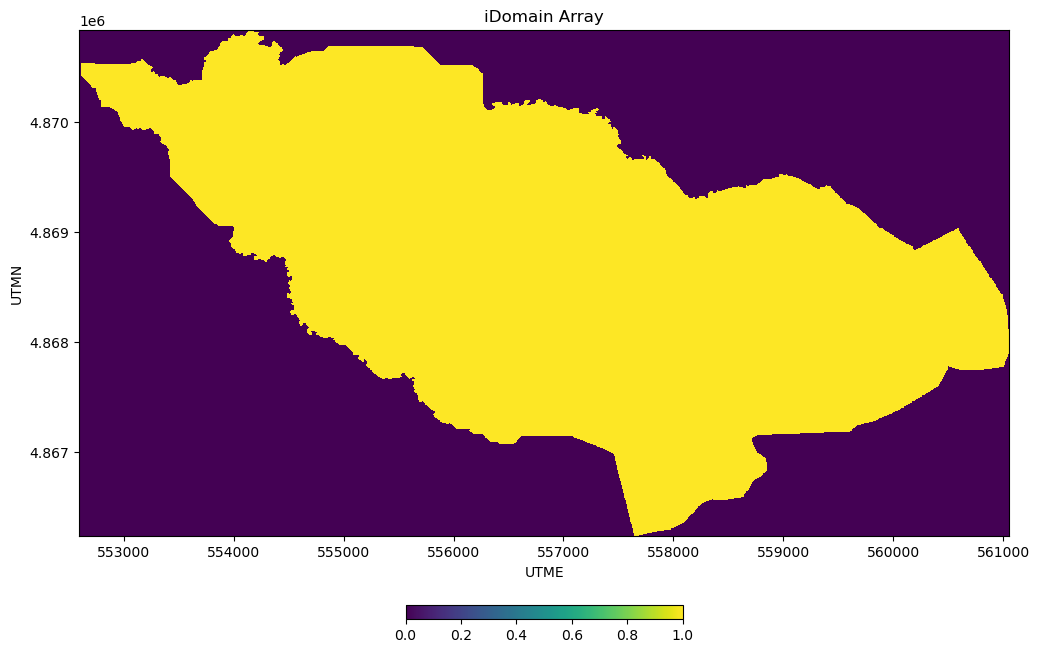

CPU times: total: 4.09 s
Wall time: 4.36 s


In [27]:
%%time

#Try using a method based on vectorization and numpy ## This appears to be the fastsest of all the methods
xc, yc = sg.xcellcenters, sg.ycellcenters #Get the cell center coords
points = np.array([(xc[i, j], yc[i, j]) for i in range(nrow) for j in range(ncol)])

#Extract the raw polygon from the GDF object subDomain
domain = subDomain.geometry.values[0]

domain = domain.buffer(0)

gi = flopy.utils.GridIntersect(sg)

idomain = np.zeros((nlay, nrow, ncol), dtype=int)

mask = vectorized.contains(domain, points[:, 0], points[:, 1])

idomain_mask = mask.reshape((nrow, ncol))
idomain[:, :, :] = idomain_mask.astype(int)

#Plot the idomain array for each layer of the model    
fig, ax = plt.subplots(figsize=(12,9))  # Create subplots in a single row
pmv = flopy.plot.PlotMapView(modelgrid=sg, layer=1)
cb = pmv.plot_array(idomain[0], ax=ax)
fig.colorbar(cb, ax=ax, orientation='horizontal', fraction=0.02, pad=0.1, shrink=0.8)
plt.title('iDomain Array')
plt.xlabel('UTME')
plt.ylabel("UTMN")
plt.show()

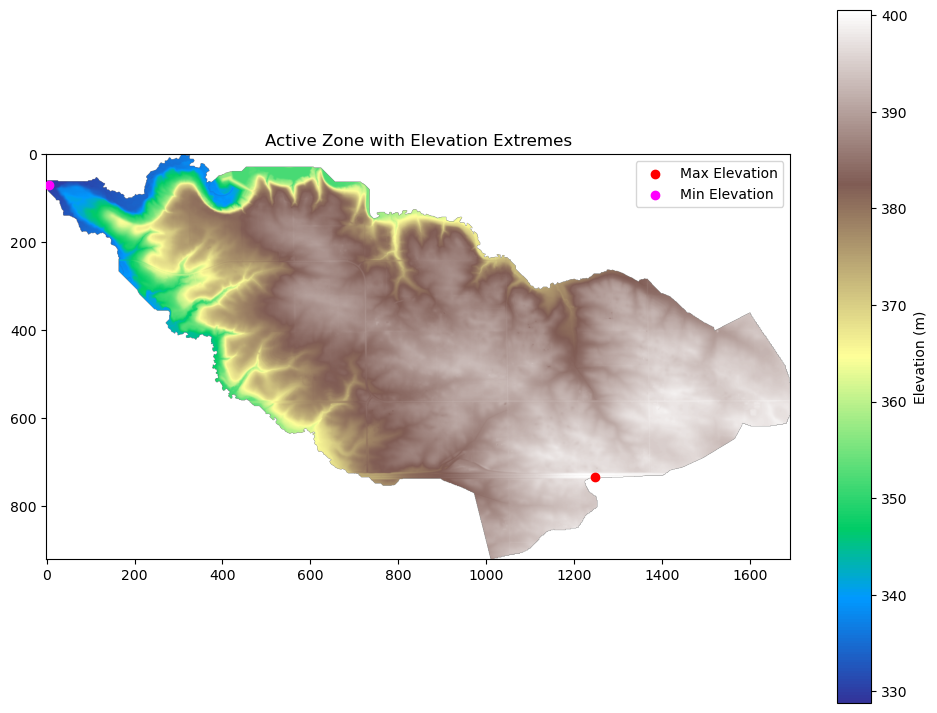

The overall surface slope of the watershed is 1.02 % to the NW
The overall slope of the watershed in degrees is 0.58 degrees
The azimuth of the slope (max elev to min elev) is 298.07 degrees
CPU times: total: 750 ms
Wall time: 890 ms


In [28]:
%%time

#Calculate the slope from the highest point in the active zone to the loweset point in the active zone
# Mask the DEM for the active zone
activeDEM = np.ma.masked_where(idomain[0] == 0, dem_grid)

# Find max and min elevations within the active zone
activeMax = np.max(activeDEM)
activeMin = np.min(activeDEM)

# Get the indices of max and min elevations in the masked array
maxIndex = np.unravel_index(np.argmax(activeDEM), activeDEM.shape)
minIndex = np.unravel_index(np.argmin(activeDEM), activeDEM.shape)

# Plot the DEM with the max and min points
fig, ax = plt.subplots(1, 1, figsize=(12, 9))
im = ax.imshow(activeDEM, cmap='terrain', origin='upper')
plt.colorbar(im, ax=ax, label='Elevation (m)')
ax.scatter(maxIndex[1], maxIndex[0], color='red', label='Max Elevation', zorder=10)
ax.scatter(minIndex[1], minIndex[0], color='magenta', label='Min Elevation', zorder=10)
ax.legend()
ax.set_title('Active Zone with Elevation Extremes')
plt.show()

#calculate the distance between these two points in m
#Get the UTME and UTMN coordinates for each of the cells
UTME1 = bounds[0] + (maxIndex[1] + 0.5) * np.average(delc)
UTME2 = bounds[0] + (minIndex[1] + 0.5) * np.average(delc)

UTMN1 = bounds[1] + (100 - maxIndex[0] + 0.5) * np.average(delr) # 100 - because the plot here counts down on the y axis
UTMN2 = bounds[1] + (100 - minIndex[0] + 0.5) * np.average(delr) # 100 - becaues the  plot here counts down on the y axis

#Calculate the distance between each point, the elevation difference, and the slope
wsH = activeMax - activeMin
wsL = np.sqrt((UTME1-UTME2)**2 + (UTMN1-UTMN2)**2)
wsSlope = wsH/wsL
print(f'The overall surface slope of the watershed is {(wsSlope* 100):.2f} % to the NW')
slopeDeg = np.arctan(wsSlope) * 180/np.pi
print(f'The overall slope of the watershed in degrees is {slopeDeg:.2f} degrees')

#determine the azimuth of the slope (to the NW)
az = np.arctan((UTME1-UTME2)/(UTMN1-UTMN2))
azDeg = az * (180/np.pi) + 360 #adding 360 because we want in azimuth convention
print(f'The azimuth of the slope (max elev to min elev) is {azDeg:.2f} degrees')

#The next step is to actually apply this azimuth and the known slope to create a bottom surface that slopes at ~1 degree in the same direction as the surface

In [30]:
activeMin

328.7981

Max elev of the Sloped bottom array 352.044
Min elev of the sloped bottom array 254.01848349608338
CPU times: total: 46.9 ms
Wall time: 69.3 ms


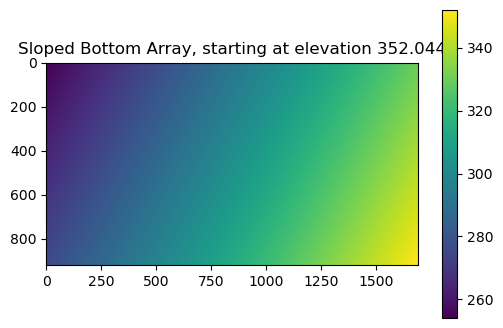

In [82]:
%%time

# Convert slope and azimuth to radians
slopeRad = np.radians(slopeDeg)
azRad = np.radians(azDeg)

#Set the max elevation that is desired
offset = 352.044

# Compute slope components in physical coordinates
slope_x = np.tan(slopeRad) * -np.sin(azRad)  # East-West component
slope_y = np.tan(slopeRad) * np.cos(azRad)  # North-South component

# Calculate physical grid dimensions
total_width = ncol * np.average(delr)  # Total width of the grid in meters
total_height = nrow * np.average(delc)  # Total height of the grid in meters

# Scale slope contributions to grid coordinates
slope_x_grid = slope_x * total_width / ncol
slope_y_grid = slope_y * total_height / nrow

# Construct the sloped surface
col_indices = np.arange(ncol)  # Columns
row_indices = np.arange(nrow)  # Rows

# Bottom Sloped array with adjusted scaling
botSloped = (offset
            - slope_x_grid * col_indices[None, :]  # x-direction slope
            - slope_y_grid * row_indices[:, None])  # y-direction slope

#Rotate the matrix into the correct orientation (there is probably a math error above but I cannot find it, so this is my solution)
botSloped = np.rot90(botSloped, 2)

print(f'Max elev of the Sloped bottom array {np.max(botSloped)}')
print(f'Min elev of the sloped bottom array {np.min(botSloped)}')

#Plot the new sloped bottom
fig, ax = plt.subplots(figsize=(6, 4))

#Plot the array as a colorplot
plot = ax.imshow(botSloped)

#Add a colorbar
plt.colorbar(plot)
plt.title(f'Sloped Bottom Array, starting at elevation {offset}')

#Use the botSloped array to replace the elvation set as the bottom of the model (botm[-1])
botm[0] = botSloped

#Use the new bottom array, as well assign new bounds to the model grid
sg.botm[0] = botm[0]   

### Assign the straight line cells between the sinkholes and Bear Spring

In [83]:
#Build a 2D bresenham algorithm for identifying cell pathways.
def bres(row1, col1, row2, col2):
    """Generate cell indices along a straight line in a 2D grid using Bresenham's algorithm."""
    cells = []
    d_row = abs(row2 - row1)
    d_col = abs(col2 - col1)
    sign_row = 1 if row2 > row1 else -1
    sign_col = 1 if col2 > col1 else -1
    err = d_col - d_row

    while (row1 != row2 or col1 != col2):
        cells.append((row1, col1))
        err2 = 2 * err
        if err2 > -d_row:
            err -= d_row
            col1 += sign_col
        if err2 < d_col:
            err += d_col
            row1 += sign_row

    cells.append((row2, col2))  # Add the last cell
    return cells

#Test this out
BSelev , iBS, jBS = get_cell_elev('55A00406') #get the elevation, cell location for Bear Spring
#Get the elevation, cell location for 55D0000054
testelev, itest, jtest = get_cell_elev('55D54')

test_path = bres(iBS, jBS, itest, jtest)

#This method appears to work as intended, so now let's apply it to each of the sinkholes
conduit_cells = []
for p in range(len(sinkhole_cells)):
    row2 = sinkhole_cells[p][2]
    col2 = sinkhole_cells[p][3]
    lineCoords = bres(iBS, jBS, row2, col2)
    conduit_cells.append(lineCoords)

## Assign Aquifer Properties

In [84]:
%%time

#Assign hydraulic conductivity (K) values for each of the layers
Kh = 1.3 #m/day for the watershed outside of the springshed
Kv = 1.3 #20.00 #m/day for the watershed outside of the springshed
Kh = np.array(Kh)
Kv = np.array(Kv)
KhBPP = 462 #m/day for the springshed polygon area
KvBPP =  462 # m/day for the springshed polygon area
K11 = Kh * np.ones((nlay, nrow, ncol))
K33 = Kv * np.ones((nlay, nrow, ncol))

#Create a list of conductivity values in the following order
#55D54
#55D1221
#55D810
#55D1208
#55D860
#55D859
#55D861
#55D1217
#55D1312

#conduit_conductivities = (5000, 2000, 8000, 7000, 6000, 5000, 4000, 3000, 1000 )

Kcond = 9000.0 #m/day

#Assign increased Kh and Kv values to the springshed area
#extract the raw polygon from the GDF object bsPolygon
bsdomain = bsPolygon.geometry.values[0]

# This also appears to be a bit of  a slow step, needs to be addressed for the high resolution model

ixbs = gi.intersect(bsdomain)
for i, j in ixbs["cellids"]:
    K11[0, i, j] = KhBPP

for i, j in ixbs["cellids"]:
    K33[0, i, j] = KvBPP
    

#THE TEXT BELOW IS WHAT IS USE TO ASSIGN THE CONDUIT CONDUCTIVITIES TO THE INDIVIDUAL CELLS
#Adjust the conductivity values for the regions with the conduits
#for j in range(len(conduit_cells)):
#    path = conduit_cells[j]
#    #K_cond = conduit_conductivities[j]
#    K_cond = Kcond
#    for i in range(len(path)):
#        row = path[i][0]
#        col = path[i][1]
#        K11[0, row, col] = K_cond

CPU times: total: 4min 25s
Wall time: 4min 43s


## Build and Run the Simulation

### Steady-State version of the model

In [ ]:
%%time
###ALL VALUES SHOULD BE IN TERMS OF PER DAY (E.G. M/DAY)

ws = './sim-01_EPM_wsgrid_simple'
name = 'EPM_wsgrid'

#generate the simulation object
sim = flopy.mf6.MFSimulation(
    sim_name=name,
    sim_ws=ws,
    exe_name='mf6',
    version = 'mf6'
)

#Build the time inputs
tuni = 'DAYS'
nper = 1 #The number of stress periods
nstp = 1 #The number of timesteps
perlen = 1.0 #The length of each stress period
tsmult = 1.0 #length of successive timesteps

#Generate the tdis object (starting w/ tdis set up for steady state model)
tdis = flopy.mf6.ModflowTdis(
    sim,
    pname = "tdis",
    time_units = tuni,
    nper = nper,
    perioddata = [(perlen, nstp, tsmult)]
)

#Create the IMS package (iterative model solver)
ims = flopy.mf6.ModflowIms(
    sim,
    pname='ims',
    inner_dvclose = 0.0001,
    outer_dvclose = 0.0001,
    linear_acceleration="BICGSTAB",
    complexity = "SIMPLE",
    print_option = "ALL",
    inner_maximum = 500,
    outer_maximum = 50
)

#Create the groundwater flow model
gwf = flopy.mf6.ModflowGwf(
    sim,
    modelname = name,
    save_flows = True,
    newtonoptions = 'NEWTON UNDER_RELAXATION'
)

#create the discretization package
dis = flopy.mf6.ModflowGwfdis(
    gwf,
    nlay = nlay,
    nrow = nrow,
    ncol = ncol,
    delr = delr,
    delc = delc,
    top = top,
    botm = botm,
    xorigin = extent[0],
    yorigin = extent[1],
    idomain = idomain,
    length_units = 'METERS'
)

# #Set up the drain which will represent Bear Spring and the river
BSelev , iBS, jBS = get_cell_elev('55A00406') #get the elevation, cell location for Bear Spring
# kBS = 2 #layer of Bear Spring (layer 1, connected to the BPP)
kBS = 0
#BS_conductance = KhBPP #set the conductance of the spring = to the BPP conductivity
BS_conductance = 400.0
BS_drain = [(kBS, iBS, jBS, BSelev, BS_conductance)] #build the Bear Spring drain list
river_drain = get_creek_cellsv3(creeks, sg, top, idomain, conductance= 1.0) #get the list of all the drain cell loations, elevs, conductances

#Get a list of all of the cells touching the border of the model not in the river_drain list
#Pad the idomain matrix so that it works with the edge cases along the matrix boundaries
idomain_pad = np.pad(idomain[0], pad_width=1, mode= 'constant', constant_values=0)

##THIS IS USED TO ADDRESS AREAS WHERE THERE IS MISMATCH BETWEEN THE ACTIVE DOMAIN AND THE RIVER LOCATIONS
#####
#Get the cells along the border in a matrix
adjacent_zeros = (
    (idomain_pad[:-2, 1:-1] == 0) | #top border
    (idomain_pad[2:, 1:-1] == 0) | #bottom border
    (idomain_pad[1:-1, :-2] == 0) | #left border
    (idomain_pad[1:-1, 2:] == 0) #right border
)

border_cells = np.argwhere(idomain == 1 & adjacent_zeros)

#Filter out all the cells where there are already drains
existing_drain_cells = {(k, i, j) for k, i, j, *_ in river_drain}

unaddressed_cells = [tuple(cell) for cell in border_cells if tuple(cell) not in existing_drain_cells]
new_cells = [cell for cell in unaddressed_cells if cell[2] <= 1000]

#Create new entries for adding to the drain list
new_river_drain_entries = [
    (k, i, j, top[i, j], 1.0)
    for k, i, j in new_cells
]
#####
all_creek_drains = river_drain + new_river_drain_entries
drnspd = BS_drain + all_creek_drains #combined list of the drain data to pass into MODFLOW DRN package ##I AM STILL HAVING ISSUES WITH THE river_drain!!

#Drain package
drn = flopy.mf6.ModflowGwfdrn(
    gwf,
    stress_period_data = drnspd,
    save_flows = True,
    print_flows = True
)

#initial conditions (estimated water table elevation)
wtElev = top - 1.58 #setting the wt elevation below the surface everywhere to start, this is pretty accurate for May 2024
strt = wtElev * np.ones((nlay ,nrow , ncol))
strt[idomain == 0] = 0 #ensure the strt array is only assigned to active cells (idomain == 1))
ic = flopy.mf6.ModflowGwfic(gwf, strt = strt)

#node property flow package
npf = flopy.mf6.ModflowGwfnpf(
    gwf,
    k = K11,
    k33 = K33,
    icelltype = 0,
    save_specific_discharge = True
)

#No storage package as the model is in steady state, thus storage is constant
# For now, set the boundary cells (idomain=2) to constant head BC
#Set up the constant head boundary condition array (assign to cells where idomain == 2)
# chdspd = []
# for k in range(nlay):
#     for i in range(nrow):
#         for j in range(ncol):
#             if idomain[k, i, j] == 2:  # boundary cells
#                 chdspd.append([(k, i, j), top[i, j]])
                
#Assign constant head package (CHD)
#chd = flopy.mf6.ModflowGwfchd(gwf, stress_period_data = chdspd)

#define evapotranspiration params
evtr = 0.015 #0.005 m is approximately the max water draw for corn at max growth stage
exdp = 2.0 #m depth where EVT turns off (1.5 m approximate max root depth for corn)

#build stress period array
evtspd = [] #initialize
for i in range(nrow):
    for j in range(ncol):
        if idomain[0, i, j] == 1:  # Use only active cells
            evtspd.append(((0, i, j), top[i, j], evtr, exdp))

stress_period_data = {0: evtspd}  # Apply to the first stress period

#Create the EVT pkg
evt = flopy.mf6.ModflowGwfevt(
    gwf,
    stress_period_data = evtspd
)

#set the recharge condition to be a very small amount of recharge
rch = flopy.mf6.ModflowGwfrcha(gwf, recharge = 0.0038) #8.11E-4 Actual recharge value, using 0.00364 m as precip input (daily average for May 2024)

#set the output control module for ease of access later
oc = flopy.mf6.ModflowGwfoc(gwf,
                            budget_filerecord=f"{name}.bud",
                            head_filerecord=f"{name}.hds",
                            printrecord=[('HEAD', 'ALL'), ('BUDGET', 'ALL')],
                            saverecord=[('HEAD', 'ALL'), ('BUDGET', 'ALL')])

CPU times: user 26.6 s, sys: 158 ms, total: 26.7 s
Wall time: 26.9 s


CPU times: user 76.9 ms, sys: 6.93 ms, total: 83.9 ms
Wall time: 82.5 ms


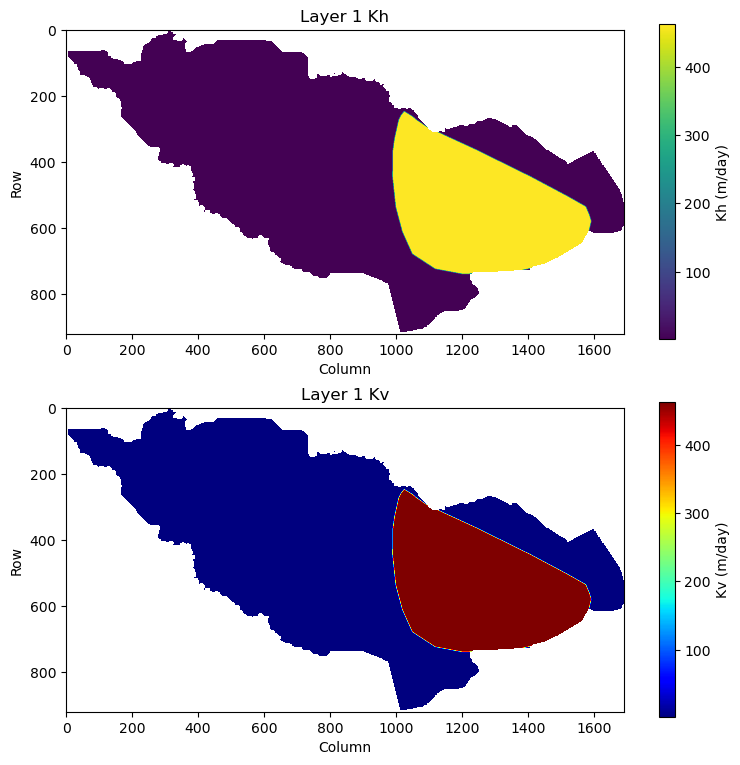

In [55]:
%%time

#Plot the Kh and Kv distributions
k11_view = npf.k.array 
k33_view = npf.k33.array

#mask out the idomain inactive cells from the array
k11_view = np.ma.masked_where(idomain == 0, k11_view)
k33_view = np.ma.masked_where(idomain == 0, k33_view)

fig, axes = plt.subplots(2, nlay, figsize=(9, 9))

for i in range(nlay):
    ax = axes[0]
    ax.set_title(f"Layer {i + 1} Kh")
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    im = ax.imshow(k11_view[i], cmap='viridis', origin='upper')
    fig.colorbar(im, ax=ax, label = 'Kh (m/day)')
    
    ax = axes[1]
    im = ax.imshow(k33_view[i], cmap='jet', origin='upper')
    ax.set_title(f"Layer {i + 1} Kv")
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    fig.colorbar(im, ax=ax, label="Kv (m/day)")


In [57]:
%%time

# write the MODFLOW input files
sim.write_simulation(silent=False)

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims...
  writing model EPM_wsgrid...
    writing model name file...
    writing package dis...
    writing package drn_0...
INFORMATION: maxbound in ('gwf6', 'drn', 'dimensions') changed to 4698 based on size of stress_period_data
    writing package ic...
    writing package npf...
    writing package evt_0...
INFORMATION: maxbound in ('gwf6', 'evt', 'dimensions') changed to 749778 based on size of stress_period_data
    writing package rcha_0...
    writing package oc...
CPU times: user 1min 55s, sys: 334 ms, total: 1min 55s
Wall time: 1min 56s


In [58]:
#run the MODFLOW simulation
sim.run_simulation(silent= False) #Set silent to False if you want to print out the messages during the simulation run

FloPy is using the following executable to run the model: ../../../../.local/share/flopy/bin/mf6
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                  VERSION 6.6.0.dev0 (preliminary) 10/18/2024
                               ***DEVELOP MODE***

   MODFLOW 6 compiled Oct 18 2024 02:59:03 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                             Build 20220726_000000

This software is preliminary or provisional and is subject to 
revision. It is being provided to meet the need for timely best 
science. The software has not received final approval by the U.S. 
Geological Survey (USGS). No warranty, expressed or implied, is made 
by the USGS or the U.S. Government as to the functionality of the 
software and related material nor shall the fact of release 
constitute any such warranty. The software is provided on the 
condition that nei

(True, [])

## Post Process the model outputs

In [59]:
%%time

# load the output from the simulation
head = gwf.output.head().get_alldata()
bud = gwf.output.budget()
spdis = bud.get_data(text='DATA-SPDIS')[0]
qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(spdis, gwf)

CPU times: user 36.9 ms, sys: 37.5 ms, total: 74.4 ms
Wall time: 141 ms


CPU times: user 43.3 s, sys: 904 ms, total: 44.2 s
Wall time: 44.4 s


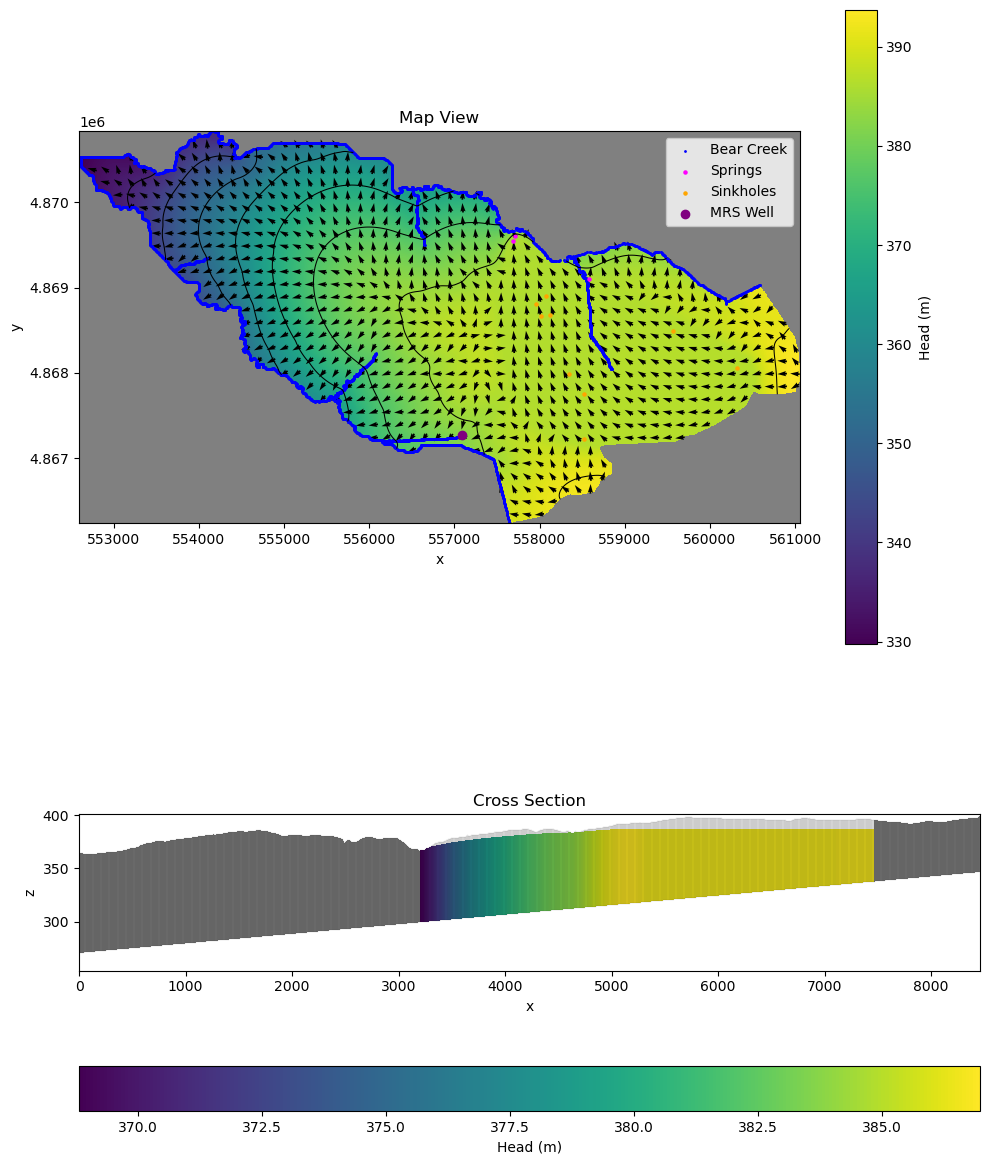

In [60]:
%%time

# create a plot of the model results
fig, axes = plt.subplots(2, 1, figsize=(10, 12))
ax = axes[0] 
ax.set_title("Map View")
ax.set_aspect(1)
ax.set_xlabel("x")
ax.set_ylabel("y")
pmv = flopy.plot.PlotMapView(gwf, ax=ax)
max_head = np.max(head[head != 1e30]) #get the max head for the colorbar
min_head = np.min(head)
#pmv.plot_bc(ftype="CHD") 
cb = pmv.plot_array(head[0][0]) #plot the head at the start of the model
pmv.plot_inactive(color_noflow="gray")
#pmv.plot_grid(color="black", linewidth=0.1)
pmv.plot_vector(qx, qy, normalize=True, color="black", istep=30, jstep=30)
pmv.contour_array(head[0][0], colors='k', linewidths = 0.75)

plt.colorbar(cb, label = "Head (m)")

# Get cell locations for Bear Creek
river_cells = [(cell[1], cell[2]) for cell in all_creek_drains]  # Extract row and column indices from river_drain
river_x = [sg.xcellcenters[row, col] for row, col in river_cells] # Get x coordinates of river cells in the grid
river_y = [sg.ycellcenters[row, col] for row, col in river_cells] # Get y coordinates of river cells in the grid

#Get the cell locations for Bear, Bear Overflow, and Hammel Springs
spring_x = [sg.xcellcenters[row, col] for name, elev, row, col in spring_cells] # Get x coordinates of river cells in the grid
spring_y = [sg.ycellcenters[row, col] for name, elev, row, col in spring_cells] # Get y coordinates of river cells in the grid

#Get the cell locations for the Sinkholes in the model
#Get the cell locations for Bear, Bear Overflow, and Hammel Springs
sinkhole_x = [sg.xcellcenters[row, col] for name, elev, row, col in sinkhole_cells] # Get x coordinates of river cells in the grid
sinkhole_y = [sg.ycellcenters[row, col] for name, elev, row, col in sinkhole_cells] # Get y coordinates of river cells in the grid

#Get the cell locations for the MRS Well in the model: MRSW UTME: 557091, UTMN: 4867265
welli, wellj = sg.intersect(557091, 4867265)

#Get the water table elevation at the MRSW:
MRS_head = head[0][0][welli][wellj]

#Plot the creek, spring, and sinkhole cells on the map
ax.scatter(river_x, river_y, color='blue', s=1, label = 'Bear Creek') # PLot the river_drain cells
ax.scatter(spring_x, spring_y, color='magenta', s=5, label = 'Springs') # PLot the spring_drain cells
ax.scatter(sinkhole_x, sinkhole_y, color = 'orange', s=5, label = 'Sinkholes')

#Plot the location of the MRSW on the Plot
ax.scatter(557091, 4867265, color='purple', label = 'MRS Well')

ax.legend(loc = 'upper right')

#Temporarily disable cross section plotting while using highly discretized grid
ax = axes[1]
ax.set_title("Cross Section")
ax.set_aspect(10.)
ax.set_xlabel("x")
ax.set_ylabel("z")
pxs = flopy.plot.PlotCrossSection(gwf, ax=ax, line={"row": int(nrow*0.75)})
pxs.plot_inactive(color_noflow="gray")
#pxs.plot_bc(ftype="CHD")
pxs.plot_array(head, head=head)
cb = pxs.plot_array(head, head=head)
pxs.plot_grid(color="black", linewidth=0.05)
plt.colorbar(cb, orientation='horizontal', label = 'Head (m)')
plt.tight_layout()

## Check for Model Errors

CPU times: user 501 ms, sys: 6.96 ms, total: 507 ms
Wall time: 508 ms


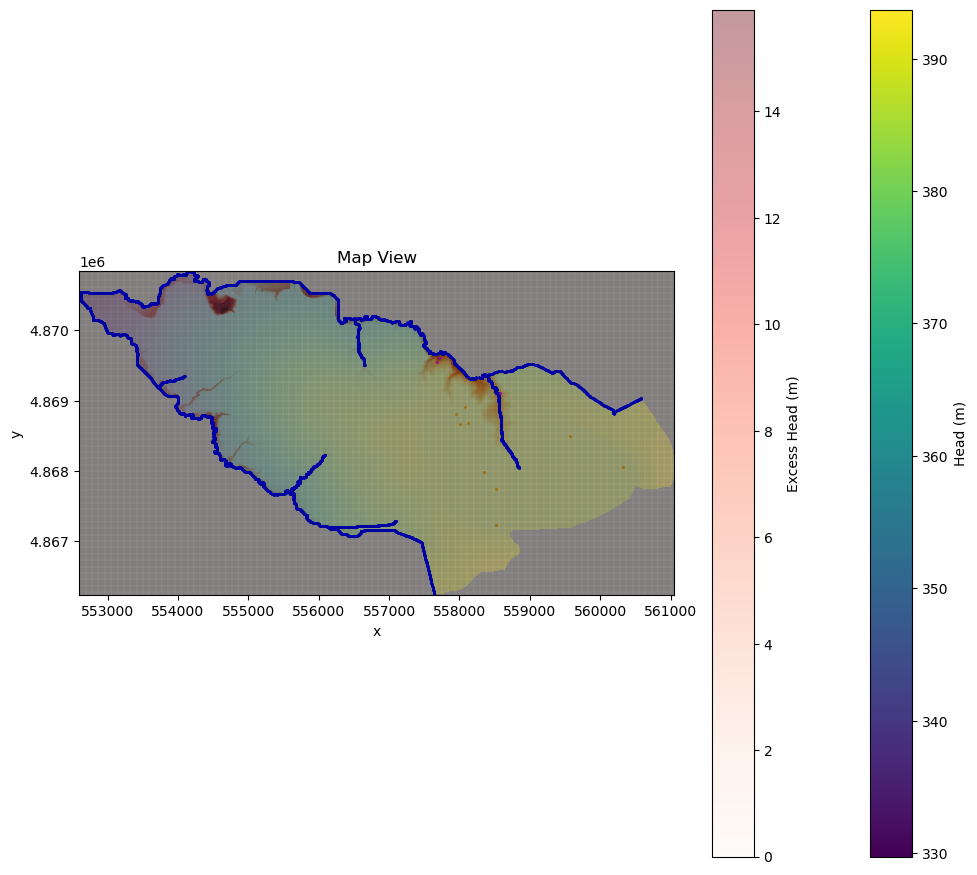

In [61]:
%%time

#Plot the locations where the hydraulic head exceeds the land surface elevation
excess_head_mask = np.zeros_like(head[0][0])
valid_mask = (head[0][0] < 1e30)  # Exclude cells with head >= 1e30
excess_head_mask[(head[0][0] > top) & valid_mask] = 1  # Mark cells with valid excess head

# Create an array to store the head difference
head_difference = np.zeros_like(excess_head_mask)  # Initialize with zeros (or np.nan if preferred)

# Record the head difference where the mask is active
head_difference = head[0][0] - top

head_difference[excess_head_mask == 0 ] = 0

# Plot the model results
fig, axes = plt.subplots(1, 1, figsize=(12, 11))
ax = axes
ax.set_title("Map View")
ax.set_aspect(1)
ax.set_xlabel("x")
ax.set_ylabel("y")

# Map view plot
pmv = flopy.plot.PlotMapView(gwf, ax=ax)
cb = pmv.plot_array(head[0][0])  # Plot the head at the start of the model
pmv.plot_inactive(color_noflow="gray")
pmv.plot_grid(color="black", linewidth=0.05)

# Overlay the excess head mask
#pmv.plot_array(excess_head_mask, cmap="Reds", alpha=0.5, label="Excess Head")
cbx = pmv.plot_array(head_difference, cmap = "Reds", alpha = 0.4, label = "Excess Head")

# Plot features
ax.scatter(river_x, river_y, color='blue', s=1, label='Bear Creek')
ax.scatter(spring_x, spring_y, color='magenta', s=1, label='Springs')
ax.scatter(sinkhole_x, sinkhole_y, color='orange', s=1, label='Sinkholes')
#ax.legend(loc='upper right')

plt.colorbar(cb, label="Head (m)")
plt.colorbar(cbx, label = "Excess Head (m)")

# # Cross-section plot
# ax = axes[1]
# ax.set_title("Cross Section")
# ax.set_aspect(10.)
# ax.set_xlabel("y")
# ax.set_ylabel("z")

# pxs = flopy.plot.PlotCrossSection(gwf, ax=ax, line={"row": int(ncol / 2)})
# pxs.plot_inactive(color_noflow="gray")
# pxs.plot_array(head, head=head)
# cb = pxs.plot_array(head, head=head)
# pxs.plot_grid(color="black", linewidth=0.5)
# plt.colorbar(cb, orientation="horizontal", label="Head (m)")

# # Tight layout for plots
# plt.tight_layout()

In [62]:
#Setup for undoing the linear indexing used to assign values to the drian cells

linear_index = 4158

k = linear_index // (nrow * ncol)  # Calculate the layer index
i = (linear_index % (nrow * ncol)) // ncol  # Calculate the row index
j = linear_index % ncol  # Calculate the column index

print(k, i, j)

0 2 774


In [63]:
#Calculate the discharge from Bear Spring

#Get the Bear Spring Coordinates
print(f'The Coordinates for Bear Spring are:{kBS, iBS, jBS}')

#get the discharge from the BS drain and River drains
cbb_file = f"{ws}/{name}.bud"
cbb = flopy.utils.CellBudgetFile(cbb_file)

#Get all of the drain data from the cbb
drn_discharge = cbb.get_data(text='DRN') #retrieve all of the DRN flows

disch_array = np.array(drn_discharge) #convert the nested array to a format where it can actually be read

#calculate the total discharge through bear spring over the entire model, units of L**3
BS_m3 = 0
for i in range(len(disch_array[:,0])): #Bear Spring is the 0th index in the drn_array
    BS_m3 = BS_m3 + disch_array[:,0][i][2] * -1
#BS_m3 = BS_m3 / 24 # ONLY RELEVANT FOR TRANSIENT MODEL #convert to the correct units to account for the hourly tsteps (raw values given in m3/day, but the # of tsteps is hourly)
print(f"Total Bear Spring Discharge: {BS_m3:.0f} m³")

#Bear Creek Drain Cells total discharge
BC_m3 = 0 #Initialize the total discharge sum

# Loop over all timesteps (720 timesteps)
for i in range(np.shape(disch_array)[0]):  # Iterate over timesteps (rows of drn_array)
    # Loop over all drains, skipping the 0th drain
    for n in range(1, np.shape(disch_array)[1]):  # Start at n=1 to skip the 0th drain
        # Access the discharge value (3rd element of the tuple)
        BC_m3 += abs(disch_array[i, n][2])  # Add the absolute discharge value
        
#BC_m3 = BC_m3 / 24 #ONLY RELEVANT FOR TRANSIENT MODEL #convert to the correct units to account for the hourly tsteps (raw values given in m3/day, but the # of tsteps is hourly)   

# Print the total discharge in cubic meters (m³)
print(f"Total Bear Creek Discharge: {BC_m3:.0f} m³")
total_drain = BC_m3 + BS_m3
print(f"Total System Discharge: {total_drain:.0f} m³")

#Get the head value in the cell that is asssociated with the Galena MRS well to use as an additional calibration check point
print(f'The Water Table Elevation in the MRS well is: {MRS_head} m')
print(f'The Depth to water in the MRS well is: {top[welli][wellj]-MRS_head}')

The Coordinates for Bear Spring are:(0, 246, 1023)
Total Bear Spring Discharge: 5328 m³
Total Bear Creek Discharge: 16730 m³
Total System Discharge: 22057 m³
The Water Table Elevation in the MRS well is: 382.20163557568316 m
The Depth to water in the MRS well is: -0.011450028808155821


In [64]:
#Temporarily stop running the code to prevent running the sensitivity analysis code below
raise SystemExit("Paused for Results Evaluation")

SystemExit: Paused for Results Evaluation

/users/1/souce015/.conda/envs/modflow6_HPC/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3406: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


### Run a sensitivity analysis for KhBPP

In [ ]:
# Define ranges for sensitivity analysis
KhBPP_values = np.linspace(1000, 10000, 20)  # 10 values between 1000 and 10000

# Initialize arrays to store results
BS_discharge_results = []
BC_discharge_results = []

#Predefine the locations where KhBPP is to limit run time
BPP_cells = np.where(K11 == KhBPP)

#Prepare the empty dataframes to accept the BC and BS discharge values
BS_discharge_results = []
BC_discharge_results = []
# Loop over parameter combinations
for KhBPP in KhBPP_values:

    print(f"Running simulation for KhBPP={KhBPP}")

    # Update hydraulic conductivity values
    K11 = Kh * np.ones((nlay, nrow, ncol))
    K33 = Kv * np.ones((nlay, nrow, ncol))

    #for i in range(len(BPP_cells[0])):
     #   row = BPP_cells[1][i] 
      #  col = BPP_cells[2][i]
       # K11[0, row, col] = KhBPP
    
    rows, cols = BPP_cells[1], BPP_cells[2]
    K11[0, rows, cols] = KhBPP
    
    # Update MODFLOW model with new parameters
    npf = flopy.mf6.ModflowGwfnpf(
        gwf,
        k=K11,
        k33=K33,
        icelltype=0,
        save_specific_discharge=True
    )

    # Run the simulation
    sim.write_simulation(silent=True)
    success, _ = sim.run_simulation(silent=True)
    if not success:
        print(f"Simulation failed for KhBPP={KhBPP}")
        BS_discharge_results.append(np.nan)
        BC_discharge_results.append(np.nan)
        continue

    # Extract discharge results
    cbb = flopy.utils.CellBudgetFile(f"{ws}/{name}.bud")
    drn_discharge = cbb.get_data(text='DRN')
    disch_array = np.array(drn_discharge)

    # Calculate Bear Spring discharge
    #BS_m3 = sum(d[:, 2] * -1 for d in disch_array[:, 0])

    # Calculate Bear Creek discharge
    #BC_m3 = sum(abs(d[:, 2]) for d in disch_array[:, 1:])

    # Calculate discharges
    #calculate the total discharge through bear spring over the entire model, units of L**3
    BS_m3 = 0
    for i in range(len(disch_array[:,0])): #Bear Spring is the 0th index in the drn_array
        BS_m3 = BS_m3 + disch_array[:,0][i][2] * -1
    
    #Bear Creek Drain Cells total discharge
    BC_m3 = 0 #Initialize the total discharge sum

    # Loop over all timesteps (720 timesteps)
    for i in range(np.shape(disch_array)[0]):  # Iterate over timesteps (rows of drn_array)
        # Loop over all drains, skipping the 0th drain
        for n in range(1, np.shape(disch_array)[1]):  # Start at n=1 to skip the 0th drain
            # Access the discharge value (3rd element of the tuple)
            BC_m3 += abs(disch_array[i, n][2])  # Add the absolute discharge value
    
    # Store results
    BS_discharge_results.append(BS_m3)
    BC_discharge_results.append(BC_m3)

# Plot results
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Spring discharge
ax[0].plot(KhBPP_values, BS_discharge_results[:len(KhBPP_values)], marker='o', label='Bear Spring')
ax[0].set_title("Spring Discharge Sensitivity")
ax[0].set_xlabel("KhBPP (m/day)")
ax[0].set_ylabel("Discharge (m³)")
ax[0].legend()

# Creek discharge
ax[1].plot(KhBPP_values, BC_discharge_results[:len(KhBPP_values)], marker='o', label='Bear Creek')
ax[1].set_title("Creek Discharge Sensitivity")
ax[1].set_xlabel("KhBPP (m/day)")
ax[1].set_ylabel("Discharge (m³)")
ax[1].legend()

plt.tight_layout()
plt.show()


## Implement MODPATH particle tracking at Bear Spring

In [ ]:
%%time
#Forward Particle Tracking

#Generate MODPATH files
mpnamf = f"{name}_mp_forward"

#Generate the modpath7 object
mp = flopy.modpath.Modpath7(
    modelname = mpnamf,
    flowmodel = gwf,
    model_ws = ws
) 


#Generate list for particle Data storge
p = [(0, i, j) for i in range(nrow) for j in range(ncol) if idomain[0, i, j] > 0]

#Generate particle data
p = flopy.modpath.ParticleData(p, structured = True)

#Generate A particle Group object
pg = flopy.modpath.ParticleGroup(particledata = p)

#Set particle data to recharge and drain along the top cell face
defaultiface = {"RECHARGE": 6,"DRAIN": 6}
porosity = 0.066 #Calculated Field Scale Porosity (MGS Pump Testing)
mpbas = flopy.modpath.Modpath7Bas(
    mp,
    porosity = porosity,
    defaultiface = defaultiface
)

#Create the simulation object for the modpath7 object
mpsim = flopy.modpath.Modpath7Sim(
    mp,
    simulationtype = "pathline",
    pathlinefilename = f'mp.pathline7',
    endpointfilename=f"mp.endpoint7",
    trackingdirection="forward",
    # weaksinkoption="pass_through",
    weaksinkoption="stop_at",
    weaksourceoption="pass_through",
    budgetoutputoption="summary",
    referencetime=[0, 0, 0.0],
    stoptimeoption="extend",
    particlegroups=[pg],
    #zonedataoption="on",
    #stopzone=2,
    #zones=zone_array
)

mp.write_input()
mp.run_model()

In [ ]:
%%time
# Get all of the tracking pathline data and plot
#load forward tracking pathline data
fpth = pl.Path(ws) / f"mp.pathline7"

#Set the coordinates for the spring and for the creek
spring_cell = (0, 24, 102)
node_spring = get_nodes([spring_cell])
#node_creek = 

p = flopy.utils.PathlineFile(fpth)
pw = p.get_destination_pathline_data(dest_cells = node_spring)
pall = p.get_alldata()

#Load forward tracking endpoint data
fpth = pl.Path(ws) / f'mp.endpoint7'

e = flopy.utils.EndpointFile(fpth)

#Get all endpoint data (epd)
all_epd = e.get_alldata()

#Get particles that terminate in wells
spr_epd = e.get_destination_endpoint_data(dest_cells = node_spring)

#Get particles that terminate in creek boundaries
#riv_epd = e.get_destination_endpoint_data(dest_cells=node_creek)

#Plot the pathline data
fig, axes = plt.subplots(ncols=1, nrows=2, sharey= True, figsize=(12,9))

ax = axes[0]
mm = flopy.plot.PlotMapView(model = gwf, ax = ax)
mm.plot_grid(lw = 0.5)
mm.plot_pathline(pw, layer = 0, colors = 'red', lw = 0.05)
pmv = flopy.plot.PlotMapView(gwf, ax=ax)
#cb = pmv.plot_array(head[0][0])  # Plot the head at the start of the model
pmv.plot_inactive(color_noflow="gray")
#Plot features
ax.scatter(river_x, river_y, color='blue', s=1, label='Bear Creek')
ax.scatter(spring_x, spring_y, color='magenta', s=1, label='Springs')
ax.scatter(sinkhole_x, sinkhole_y, color='orange', s=1, label='Sinkholes')
ax.legend()

ax = axes[1]
mm = flopy.plot.PlotMapView(model = gwf, ax = ax)
mm.plot_grid(lw = 0.5)
mm.plot_endpoint(spr_epd, direction="starting", colorbar=True, shrink=0.5)
mm.plot_inactive(color_noflow="gray")
#Plot the features
ax.scatter(river_x, river_y, color='blue', s=1, label='Bear Creek')
ax.scatter(spring_x, spring_y, color='magenta', s=1, label='Springs')
ax.scatter(sinkhole_x, sinkhole_y, color='orange', s=1, label='Sinkholes')
ax.legend()

In [ ]:
print(f"Number of pathlines to spring: {len(pw)}")
print(f"Number of Cells that end at the spring {len(spr_epd)}")

In [ ]:
#Using Sinkhole 55D1312
node_source = get_nodes([(0, get_cell_elev('55D1208')[1], get_cell_elev('55D1208')[2])])
print(f'The Sinkhole node is: {node_source}')

In [ ]:
epd_df = pd.DataFrame.from_records(all_epd)
epd_df.head()
#stranded_particles = epd_df[epd_df['termination'] == 'INACTIVE']
epd_df['status']

In [ ]:
input_node = 7377  # Example input node value 55D1312
output_node = 4158  # Example output node value BearSpring

spr_epd_df = pd.DataFrame.from_records(spr_epd)
np.where(spr_epd_df['node0'] == input_node)
#spr_epd_df.head()
spr_epd_df.iloc[316]